# Novae GNN embeddings from spatial transcriptomics

compute 64-d spot embeddings via Novae (Blampey et al. 2025, Nat. Methods) on raw counts from Wang et al.
TNBC co-registered ST. these embeddings pair with UNI2 1536-d H&E embeddings for cross-modal
contrastive alignment into a shared 512-d space.

**key uncertainty**: Novae was trained on **image-based ST** (MERSCOPE, Xenium, CosMX) - subcellular
resolution platforms with fundamentally different spatial structure than spot-based ST. Wang et al. uses
a custom array platform with 200 um spots. the zero-shot generalization claim covers gene panel
diversity, but platform generalization (image-based -> spot-based) is empirical, not guaranteed.
the QC gates in this notebook are the actual experiment, not a precaution.

**additional mismatches**:
- spot size: 200 um (Wang) vs subcellular (~0.5 um, Novae training)
- genes/spot: up to 27k (Wang, 200-cell spots) vs single-cell panels
- spatial graph: edges ~200 um vs ~10-50 um in training data

**questions this notebook answers:**

1. what are the count statistics and how do they compare to Novae's expected input?
2. what fraction of Novae's expected gene panel is present in the Wang et al. data?
3. does the 200 um spot spacing affect spatial graph construction relative to training context?
4. do Novae embeddings (64-d) collapse on this tissue, or capture biological variation?
5. do embeddings preserve spatial structure (nearby spots -> similar embeddings)?
6. should we proceed with Novae or fall back to PCA on HVGs as the ST baseline?

**fallback criteria** (if either fails, switch to PCA on HVGs before blaming alignment):
- within-patient similarity gap < 0.05 -> embeddings don't capture patient-level biology
- spatial autocorrelation rho > -0.1 -> embeddings are spatially uninformative

for comparison, UNI2 achieved: within/between gap = 0.138, spatial rho = -0.413


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import io
from pathlib import Path

ROOT = Path().resolve().parents[1]
DATA = ROOT / 'data' / 'inputs'
by_array = DATA / 'byArray'

sns.set_theme(style='ticks', palette='Dark2', context='notebook')

# use the same 5 subarrays as the UNI2 notebook for direct comparison
SELECTED_SUBARRAYS = [
    ('TNBC55', 'CN28', 'C1'),
    ('TNBC3', 'CN2', 'C1'),
    ('TNBC68', 'CN34', 'D2'),
    ('TNBC83', 'CN42', 'C1'),
    ('TNBC1', 'CN1', 'C1'),
]

## 1. load raw counts from selection.RData

the encoder_input_decision (resolved in EDA) confirmed that `selection.RData` contains raw integer
counts for tissue-filtered spots, stored as a matrix `cnts` (spots x genes, Ensembl IDs) and a
data.frame `spots` with coordinates. `rawCountsMatrices/` contains normalized floats despite the name.

In [2]:
def load_selection_rdata(slide, position):
    """load raw counts and spot coordinates from selection.RData via Rscript."""
    rdata_path = by_array / slide / position / 'selection.RData'
    assert rdata_path.exists(), f'missing: {rdata_path}'

    # extract counts matrix as CSV
    r = subprocess.run(['Rscript', '-e', f'''
        load("{rdata_path}")
        write.csv(cnts, stdout())
    '''], capture_output=True, text=True)
    assert r.returncode == 0, f'Rscript failed: {r.stderr[:200]}'
    counts = pd.read_csv(io.StringIO(r.stdout), index_col=0)

    # extract spot coordinates
    r2 = subprocess.run(['Rscript', '-e', f'''
        load("{rdata_path}")
        write.csv(spots, stdout())
    '''], capture_output=True, text=True)
    coords = pd.read_csv(io.StringIO(r2.stdout), index_col=0)

    return counts, coords

# load all 5 subarrays
all_counts = {}
all_coords = {}
for tnbc_id, slide, pos in SELECTED_SUBARRAYS:
    key = f'{tnbc_id}_{slide}_{pos}'
    counts, coords = load_selection_rdata(slide, pos)
    all_counts[key] = counts
    all_coords[key] = coords
    print(f'{key}: {counts.shape[0]} spots x {counts.shape[1]} genes')

print(f'\ntotal spots: {sum(c.shape[0] for c in all_counts.values())}')

TNBC55_CN28_C1: 542 spots x 19068 genes
TNBC3_CN2_C1: 701 spots x 24232 genes
TNBC68_CN34_D2: 697 spots x 21297 genes
TNBC83_CN42_C1: 1398 spots x 26326 genes
TNBC1_CN1_C1: 1075 spots x 27567 genes

total spots: 4413


## 2. count statistics vs Novae's expected input

Novae was trained on 10x Visium data with:
- 55 um spot diameter, ~4992 spots per array
- ~4000 median genes/spot (typical Visium)
- ~15000-20000 median UMI/spot

Wang et al. uses a custom ST platform with 200 um spots (100 um center-to-center). each spot
captures up to 200 cells, so counts are higher per spot but spatial resolution is coarser.
the question is whether Novae's learned representations generalize to this different count distribution.

In [3]:
# per-subarray count statistics
stats = []
for key, counts in all_counts.items():
    total_counts = counts.sum(axis=1)
    genes_detected = (counts > 0).sum(axis=1)
    sparsity = (counts == 0).values.mean()
    stats.append({
        'subarray': key,
        'n_spots': counts.shape[0],
        'n_genes': counts.shape[1],
        'median_umi': total_counts.median(),
        'median_genes': genes_detected.median(),
        'mean_umi': total_counts.mean(),
        'mean_genes': genes_detected.mean(),
        'sparsity': sparsity,
    })

stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

# Novae reference range
print(f'\n--- Novae expected range (10x Visium) ---')
print(f'median genes/spot: ~4000')
print(f'median UMI/spot: ~15000-20000')
print(f'\n--- Wang et al. (this dataset) ---')
print(f'median genes/spot range: {stats_df["median_genes"].min():.0f} - {stats_df["median_genes"].max():.0f}')
print(f'median UMI/spot range: {stats_df["median_umi"].min():.0f} - {stats_df["median_umi"].max():.0f}')

# flag subarrays below Novae's expected range
low_gene = stats_df[stats_df['median_genes'] < 2000]
if len(low_gene) > 0:
    print(f'\nWARNING: {len(low_gene)} subarrays have median genes/spot < 2000 (below Novae training range):')
    print(low_gene[['subarray', 'median_genes', 'median_umi']].to_string(index=False))

      subarray  n_spots  n_genes  median_umi  median_genes     mean_umi  mean_genes  sparsity
TNBC55_CN28_C1      542    19068       244.0         196.5  2285.555351  778.348708  0.959180
  TNBC3_CN2_C1      701    24232     27557.0        5407.0 29482.931526 5319.456491  0.780478
TNBC68_CN34_D2      697    21297      1489.0         873.0  2564.269727 1217.539455  0.942830
TNBC83_CN42_C1     1398    26326      7853.5        2608.5  8573.734621 2642.923462  0.899608
  TNBC1_CN1_C1     1075    27567     16492.0        4399.0 18874.521860 4405.307907  0.840196

--- Novae expected range (10x Visium) ---
median genes/spot: ~4000
median UMI/spot: ~15000-20000

--- Wang et al. (this dataset) ---
median genes/spot range: 196 - 5407
median UMI/spot range: 244 - 27557

      subarray  median_genes  median_umi
TNBC55_CN28_C1         196.5       244.0
TNBC68_CN34_D2         873.0      1489.0


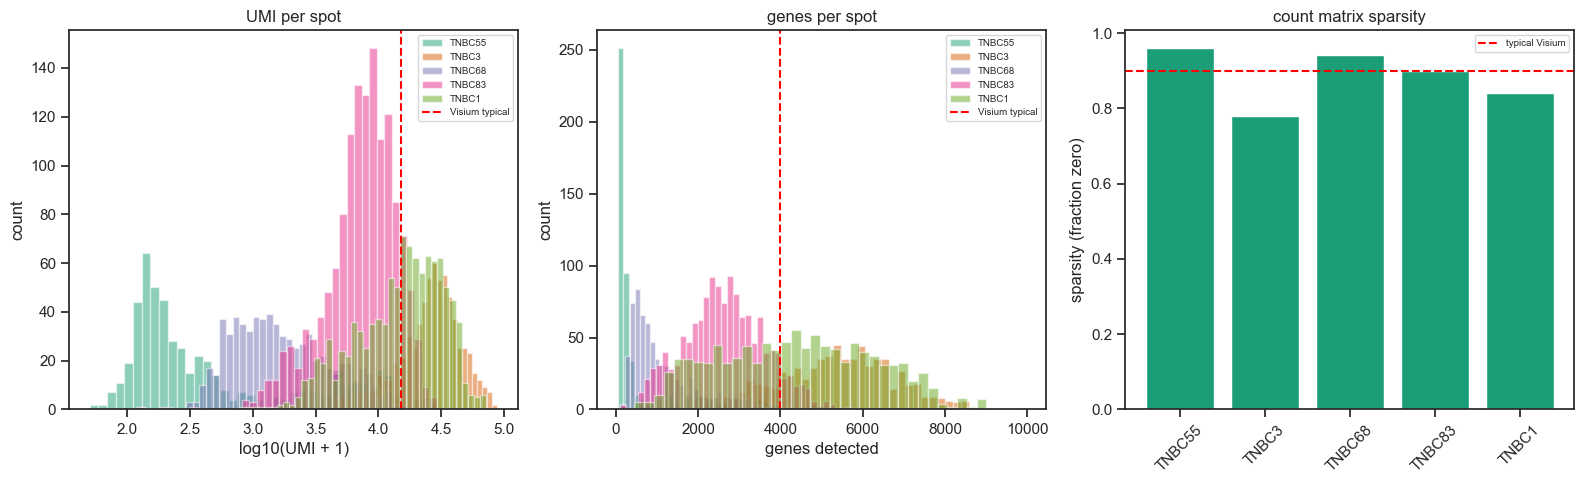

In [4]:
# visualize count distributions across subarrays
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for key, counts in all_counts.items():
    total_counts = counts.sum(axis=1)
    genes_detected = (counts > 0).sum(axis=1)
    short_key = key.split('_')[0]  # TNBC id only
    axes[0].hist(np.log10(total_counts + 1), bins=40, alpha=0.5, label=short_key)
    axes[1].hist(genes_detected, bins=40, alpha=0.5, label=short_key)

axes[0].set_xlabel('log10(UMI + 1)')
axes[0].set_ylabel('count')
axes[0].set_title('UMI per spot')
axes[0].axvline(np.log10(15000), color='red', ls='--', label='Visium typical')
axes[0].legend(fontsize=7)

axes[1].set_xlabel('genes detected')
axes[1].set_ylabel('count')
axes[1].set_title('genes per spot')
axes[1].axvline(4000, color='red', ls='--', label='Visium typical')
axes[1].legend(fontsize=7)

# sparsity comparison
sparsities = [stats_df.loc[i, 'sparsity'] for i in range(len(stats_df))]
axes[2].bar(range(len(stats_df)), sparsities)
axes[2].set_xticks(range(len(stats_df)))
axes[2].set_xticklabels([s.split('_')[0] for s in stats_df['subarray']], rotation=45)
axes[2].set_ylabel('sparsity (fraction zero)')
axes[2].set_title('count matrix sparsity')
axes[2].axhline(0.9, color='red', ls='--', label='typical Visium')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 2b. per-subarray QC gate

not all subarrays are viable Novae inputs. route each subarray based on median genes/spot:
- >= 2000: run Novae (within expected input range)
- 500-1999: run Novae but flag as marginal (below training range, results may be noisy)
- < 500: fall back to PCA on HVGs immediately (too sparse for Novae to produce signal)

subarrays routed to fallback are excluded from Novae inference but retained for PCA baseline.


In [5]:
# per-subarray routing decision - apply before building AnnData
MIN_MEDIAN_GENES = 500

routing = {}
for s in stats:
    key = s['subarray']
    if s['median_genes'] >= 2000:
        routing[key] = 'novae'
    elif s['median_genes'] >= MIN_MEDIAN_GENES:
        routing[key] = 'novae_flagged'
    else:
        routing[key] = 'hvg_pca_fallback'
    print(f"{key}: {s['median_genes']:.0f} median genes -> {routing[key]}")

# only pass non-fallback subarrays forward to Novae
novae_keys = {k for k, v in routing.items() if v != 'hvg_pca_fallback'}
fallback_keys = {k for k, v in routing.items() if v == 'hvg_pca_fallback'}
all_counts_novae = {k: v for k, v in all_counts.items() if k in novae_keys}
all_coords_novae = {k: v for k, v in all_coords.items() if k in novae_keys}

if fallback_keys:
    print(f'\nexcluded from Novae (routed to PCA fallback): {fallback_keys}')
print(f'proceeding with {len(novae_keys)} subarrays for Novae inference')


TNBC55_CN28_C1: 196 median genes -> hvg_pca_fallback
TNBC3_CN2_C1: 5407 median genes -> novae
TNBC68_CN34_D2: 873 median genes -> novae_flagged
TNBC83_CN42_C1: 2608 median genes -> novae
TNBC1_CN1_C1: 4399 median genes -> novae

excluded from Novae (routed to PCA fallback): {'TNBC55_CN28_C1'}
proceeding with 4 subarrays for Novae inference


## 3. gene panel intersection with Novae

Novae uses highly variable genes (HVGs) from its training data. if the Wang et al. gene panel
has low overlap with Novae's expected genes, the model is effectively extrapolating from limited
input features. we check the intersection between our gene panel and what Novae expects.

note: Novae typically selects HVGs internally during preprocessing. the question is whether the
raw gene set in our data provides sufficient coverage for Novae to select meaningful HVGs.

In [6]:
# gene panel overview across subarrays
all_genes = set()
per_subarray_genes = {}
for key, counts in all_counts.items():
    genes = set(counts.columns)
    per_subarray_genes[key] = genes
    all_genes |= genes
    print(f'{key}: {len(genes)} genes')

# intersection across all subarrays
common_genes = set.intersection(*per_subarray_genes.values())
print(f'\nunion: {len(all_genes)} genes')
print(f'intersection (all 5 subarrays): {len(common_genes)} genes')

# gene ID format check - Novae expects gene symbols, not Ensembl
sample_genes = list(list(per_subarray_genes.values())[0])[:5]
print(f'\ngene ID format: {sample_genes}')
is_ensembl = any(g.startswith('ENSG') for g in sample_genes)
if is_ensembl:
    print('genes are Ensembl IDs - will need to map to symbols for Novae')
    # check if mapping file exists
    mapping_file = DATA / 'ensembl_to_symbol.tsv'
    if mapping_file.exists():
        gene_map = pd.read_csv(mapping_file, sep='\t')
        print(f'mapping file: {len(gene_map)} entries')
        # strip version from Ensembl IDs for matching
        ensembl_no_version = {g.split('.')[0] for g in all_genes}
        map_ensembl = set(gene_map.iloc[:, 0])
        mapped = ensembl_no_version & map_ensembl
        print(f'mappable to symbols: {len(mapped)} / {len(ensembl_no_version)} ({len(mapped)/len(ensembl_no_version):.0%})')
    else:
        print(f'mapping file not found at {mapping_file} - will need to create')

TNBC55_CN28_C1: 19068 genes
TNBC3_CN2_C1: 24232 genes
TNBC68_CN34_D2: 21297 genes
TNBC83_CN42_C1: 26326 genes
TNBC1_CN1_C1: 27567 genes

union: 34617 genes
intersection (all 5 subarrays): 15215 genes

gene ID format: ['ENSG00000145685.13', 'ENSG00000183979.7', 'ENSG00000171490.12', 'ENSG00000137947.11', 'ENSG00000234230.1']
genes are Ensembl IDs - will need to map to symbols for Novae
mapping file: 48698 entries
mappable to symbols: 27351 / 34617 (79%)


## 4. build AnnData objects for Novae

Novae expects AnnData with:
- `.X`: raw counts
- `.obs`: spot metadata
- `.obsm['spatial']`: spot coordinates
- `.var_names`: gene symbols (not Ensembl IDs)

we build one AnnData per subarray, map Ensembl -> gene symbols, and construct the spatial graph.

In [7]:
# verify coordinate column names match expectations
sample_key = list(all_coords_novae.keys())[0]
sample_coords = all_coords_novae[sample_key]
print(f'coordinate columns: {sample_coords.columns.tolist()}')
print(f'sample values:')
print(sample_coords.head(3))
assert 'pixel_x' in sample_coords.columns and 'pixel_y' in sample_coords.columns, \
    f'expected pixel_x/pixel_y columns, got: {sample_coords.columns.tolist()}'
print('\npixel_x/pixel_y confirmed - matches AnnData construction below')


coordinate columns: ['x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y']
sample values:
        x   y  new_x  new_y  pixel_x  pixel_y
20x54  20  54  20.00  54.00   3395.7   6579.1
21x53  21  53  21.02  53.01   3506.4   6460.7
22x40  22  40  22.02  39.98   3613.4   4893.2

pixel_x/pixel_y confirmed - matches AnnData construction below


In [8]:
import anndata as ad
import scanpy as sc
from scipy.sparse import csr_matrix

# load Ensembl -> symbol mapping
mapping_file = DATA / 'ensembl_to_symbol.tsv'
gene_map_df = pd.read_csv(mapping_file, sep='\t')
# build dict: ensembl_id (no version) -> gene symbol
ensembl_to_symbol = dict(zip(gene_map_df.iloc[:, 0], gene_map_df.iloc[:, 1]))

adatas = {}
for key, counts in all_counts_novae.items():
    coords = all_coords_novae[key]

    # map gene IDs: strip version, convert to symbol
    ensembl_ids = counts.columns.tolist()
    symbols = []
    keep_mask = []
    for eid in ensembl_ids:
        base = eid.split('.')[0]
        if base in ensembl_to_symbol:
            symbols.append(ensembl_to_symbol[base])
            keep_mask.append(True)
        else:
            keep_mask.append(False)

    # filter to mappable genes, deduplicate symbols (sum duplicates)
    counts_mapped = counts.loc[:, keep_mask].copy()
    counts_mapped.columns = symbols

    # build ensembl mapping before dedup (symbol -> first ensembl id)
    symbol_to_ensembl = {}
    for eid, sym, kept in zip(ensembl_ids, symbols + [''] * (len(ensembl_ids) - len(symbols)), keep_mask):
        if kept and sym not in symbol_to_ensembl:
            symbol_to_ensembl[sym] = eid.split('.')[0]

    # sum duplicate gene symbols
    counts_mapped = counts_mapped.T.groupby(level=0).sum().T

    adata = ad.AnnData(
        X=csr_matrix(counts_mapped.values),
        obs=pd.DataFrame(index=counts_mapped.index),
        var=pd.DataFrame(index=counts_mapped.columns),
    )
    adata.obs['subarray'] = key
    adata.obsm['spatial'] = coords[['pixel_x', 'pixel_y']].values

    # store ensembl IDs aligned to deduped var_names
    adata.var['ensembl_id'] = [symbol_to_ensembl.get(s, '') for s in adata.var_names]

    adatas[key] = adata
    n_mapped = sum(keep_mask)
    n_deduped = len(symbols) - adata.n_vars
    print(f'{key}: {adata.n_obs} spots x {adata.n_vars} genes (mapped {n_mapped}/{len(ensembl_ids)}, {n_deduped} duplicates summed)')

print(f'\ntotal spots across adatas: {sum(a.n_obs for a in adatas.values())}')


TNBC3_CN2_C1: 701 spots x 20420 genes (mapped 20493/24232, 73 duplicates summed)
TNBC68_CN34_D2: 697 spots x 18420 genes (mapped 18471/21297, 51 duplicates summed)
TNBC83_CN42_C1: 1398 spots x 21876 genes (mapped 21999/26326, 123 duplicates summed)
TNBC1_CN1_C1: 1075 spots x 22660 genes (mapped 22804/27567, 144 duplicates summed)

total spots across adatas: 3871


## 5. spatial graph construction

Novae operates on a spatial graph where each spot is connected to its k nearest neighbors.
standard Visium uses k=6 for the hexagonal grid with 55 um center-to-center spacing.

Wang et al. spots are 200 um center-to-center - graph edges are ~3.6x longer than Novae's
training context. the spatial receptive field of each GNN layer therefore covers a physically
larger area, which could either help (more tissue context per message-passing step) or hurt
(spatial relationships learned at 55 um don't transfer to 200 um).

In [9]:
from scipy.spatial import KDTree

# build k-NN spatial graph for each subarray
K_NEIGHBORS = 6  # standard for hex Visium grid

for key, adata in adatas.items():
    coords = adata.obsm['spatial']
    tree = KDTree(coords)
    dists, indices = tree.query(coords, k=K_NEIGHBORS + 1)  # +1 for self

    # exclude self-connection
    neighbor_dists = dists[:, 1:]  # skip distance to self
    median_nn_dist = np.median(neighbor_dists[:, 0])  # nearest neighbor distance

    print(f'{key}:')
    print(f'  median nearest-neighbor distance: {median_nn_dist:.1f} pixels')
    print(f'  k={K_NEIGHBORS} neighbor distance range: {neighbor_dists.min():.1f} - {neighbor_dists.max():.1f}')

print(f'\n--- spatial scale comparison ---')
print(f'Visium (Novae training): 55 um center-to-center')
print(f'Wang et al. (this data): 200 um center-to-center')
print(f'ratio: ~3.6x - each GNN message-passing step covers a larger physical area')

TNBC3_CN2_C1:
  median nearest-neighbor distance: 158.3 pixels
  k=6 neighbor distance range: 142.6 - 647.6
TNBC68_CN34_D2:
  median nearest-neighbor distance: 158.5 pixels
  k=6 neighbor distance range: 141.1 - 431.8
TNBC83_CN42_C1:
  median nearest-neighbor distance: 159.0 pixels
  k=6 neighbor distance range: 140.6 - 378.3
TNBC1_CN1_C1:
  median nearest-neighbor distance: 158.6 pixels
  k=6 neighbor distance range: 143.1 - 643.8

--- spatial scale comparison ---
Visium (Novae training): 55 um center-to-center
Wang et al. (this data): 200 um center-to-center
ratio: ~3.6x - each GNN message-passing step covers a larger physical area


## 6. install Novae and run inference

Novae produces 256-d embeddings per spot via a graph neural network that learns spatial
gene expression patterns. the model uses message passing on the spatial graph to aggregate
neighborhood context into each spot's representation.

In [10]:
# install novae if needed
import sys
try:
    import novae
    print(f'novae: {novae.__version__}')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'novae'])
    import novae
    print(f'novae installed: {novae.__version__}')

# check available pretrained model names before inference
try:
    available = novae.utils.available_models()
    print(f'available models: {available}')
except AttributeError:
    # API may differ - check novae docs for model listing
    print('novae.utils.available_models() not available - check docs for model names')
    print(dir(novae.Novae))


novae: 1.0.3
novae.utils.available_models() not available - check docs for model names
['CHECKPOINT_HYPER_PARAMS_KEY', 'CHECKPOINT_HYPER_PARAMS_NAME', 'CHECKPOINT_HYPER_PARAMS_TYPE', 'T_destination', '_LightningModule__check_allowed', '_LightningModule__check_not_nested', '_LightningModule__to_tensor', '__annotate_func__', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__jit_unused_properties__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_apply_batch_transfer_handler', '_call_batch_hook', '_call_impl', '_compiled_call_impl', '_compute_leaves', '_compute_representations_datamodule', '_decode_arg', '_embed

In [11]:
%%time
# run Novae inference on each subarray
# novae API: spatial_neighbors(adata) -> model.compute_representations(adata)
# embeddings stored in adata.obsm['novae_latent'] (64-d, not 256-d as originally assumed)

# coordinates are in pixel space (~164 px median neighbor distance)
# the HD images have 0.2774 um/pixel (from UNI2 notebook)
# but spot coords are in HE-small space (9523x9523), not HD space
# spot spacing is ~200 um center-to-center, median pixel distance ~164
# so um_per_pixel in spot coord space = 200 / 164 ~= 1.22
# set scale_to_microns so Novae interprets distances correctly
UM_PER_PIXEL_SPOT = 200.0 / 164.0  # approximate from known spot spacing
novae.settings.scale_to_microns = UM_PER_PIXEL_SPOT
print(f'scale_to_microns: {UM_PER_PIXEL_SPOT:.4f} (200 um spot spacing / ~164 px median distance)')

all_embeddings = {}

model = novae.Novae.from_pretrained('MICS-Lab/novae-human-0')

for key, adata in adatas.items():
    print(f'\n{key}: {adata.n_obs} spots x {adata.n_vars} genes')

    # build spatial neighbor graph (Delaunay triangulation by default)
    novae.spatial_neighbors(adata)

    # compute embeddings
    model.compute_representations(adata, zero_shot=True)

    # embeddings are in 'novae_latent' (64-d)
    emb_key = 'novae_latent'

    emb = adata.obsm[emb_key].copy()
    if hasattr(emb, 'values'):
        emb = emb.values
    print(f'  obsm keys: {list(adata.obsm.keys())}')
    print(f'  embedding shape: {emb.shape}')
    print(f'  embedding range: [{emb.min():.3f}, {emb.max():.3f}]')
    # preserve spot IDs (adata.obs_names = coordinate IDs e.g. '20x54')
    all_embeddings[key] = pd.DataFrame(
        emb,
        index=adata.obs_names,
        columns=[f'novae_{i}' for i in range(emb.shape[1])]
    )

    # niche definition: k=6 spatial neighbors per spot (matches Virchow2 niche)
    # KDTree on pixel coords, drop self, map indices -> spot_id strings
    # downstream niche agg: mean-pool embedding over these 6 ids (+ self, per-subarray)
    _tree = KDTree(adata.obsm['spatial'])
    _, _nbr_idx = _tree.query(adata.obsm['spatial'], k=K_NEIGHBORS + 1)
    _obs_arr = np.asarray(adata.obs_names)
    all_embeddings[key]['neighbor_spot_ids'] = [
        _obs_arr[row[1:]].tolist() for row in _nbr_idx
    ]

# stack all embeddings for global analysis (skip the list column)
_emb_cols = [f'novae_{i}' for i in range(64)]
embeddings_all = np.vstack([v[_emb_cols].values for v in all_embeddings.values()])
labels_all = np.concatenate([[k] * len(v) for k, v in all_embeddings.items()])
print(f'\ntotal embeddings: {embeddings_all.shape}')
print(f'\nnote: Novae produces 64-d embeddings, not 256-d as in the original proposal')
print('CLAUDE.md and MODELS.md need updating: 256-d -> 64-d')

OUT = ROOT / 'data' / 'embeddings' / 'novae'
OUT.mkdir(parents=True, exist_ok=True)
for key, emb_df in all_embeddings.items():
    emb_df.index.name = 'spot_id'
    emb_df['subarray'] = key
    emb_df.to_parquet(OUT / f'{key}_novae_embeddings.parquet')
print(f'saved {len(all_embeddings)} parquets -> {OUT}')
print(f'columns per parquet: 64 novae_* + neighbor_spot_ids (k=6 list) + subarray')


scale_to_microns: 1.2195 (200 um spot spacing / ~164 px median distance)


[INFO] (novae.utils.build) Computing graph on 701 cells (coord_type=generic, delaunay=True, radius=None, n_neighs=None)
[WARNING] (novae.utils.build) The maximum distance between neighbors is 4550.3, which is very high compared to the mean distance of 215.8.
 Consider re-running `novae.spatial_neighbors` with a different `radius` threshold.
[WARNING] (novae.utils._validate) The average median distance between neighboring cells seems high (200.91). If your coordinates are not in microns, set `novae.settings.scale_to_microns` to the conversion factor from your coordinate units to microns, e.g., `0.2125` if you use Xenium pixels.



TNBC3_CN2_C1: 701 spots x 20420 genes


[INFO] (novae.utils._validate) Preprocessed 1 adata object(s) with sc.pp.normalize_total and sc.pp.log1p (raw counts were saved in adata.layers['counts'])


Computing representations:   0%|          | 0/2 [00:00<?, ?it/s]

...

Computing representations:   0%|          | 0/3 [00:00<?, ?it/s]

[INFO] (novae.utils.build) Computing graph on 1,075 cells (coord_type=generic, delaunay=True, radius=None, n_neighs=None)
[WARNING] (novae.utils.build) The maximum distance between neighbors is 5529.6, which is very high compared to the mean distance of 217.6.
 Consider re-running `novae.spatial_neighbors` with a different `radius` threshold.
[WARNING] (novae.utils._validate) The average median distance between neighboring cells seems high (200.03). If your coordinates are not in microns, set `novae.settings.scale_to_microns` to the conversion factor from your coordinate units to microns, e.g., `0.2125` if you use Xenium pixels.
[INFO] (novae.utils._validate) Preprocessed 1 adata object(s) with sc.pp.normalize_total and sc.pp.log1p (raw counts were saved in adata.layers['counts'])


  obsm keys: ['spatial', 'novae_latent']
  embedding shape: (1398, 64)
  embedding range: [-1.368, 1.327]

TNBC1_CN1_C1: 1075 spots x 22660 genes


Computing representations:   0%|          | 0/3 [00:00<?, ?it/s]

  obsm keys: ['spatial', 'novae_latent']
  embedding shape: (1075, 64)
  embedding range: [-1.316, 1.316]

total embeddings: (3871, 64)

note: Novae produces 64-d embeddings, not 256-d as in the original proposal
CLAUDE.md and MODELS.md need updating: 256-d -> 64-d
saved 4 parquets -> /Users/sanati/BForePC/omicstra/data/embeddings/novae
columns per parquet: 64 novae_* + neighbor_spot_ids (k=6 list) + subarray
CPU times: user 45.4 s, sys: 14.1 s, total: 59.5 s
Wall time: 40.2 s


In [12]:
# check if Novae L2-normalizes embeddings before storing
# if unit-normalized (std ~ 0): embeddings live on a hypersphere
#   -> ST projection MLP doesn't need explicit norm layer at input
# if raw GAT output (std >> 0): needs normalization before alignment
#   -> different design from UNI2 side (raw CLS tokens)

norms = np.linalg.norm(embeddings_all, axis=1)
print(f'L2 norm stats: mean={norms.mean():.3f}, std={norms.std():.4f}, min={norms.min():.3f}, max={norms.max():.3f}')

if norms.std() < 0.01:
    print('-> unit normalized (hypersphere) - no input normalization needed in projection MLP')
else:
    print(f'-> raw GAT output (norms vary {norms.min():.2f} to {norms.max():.2f})')
    print('   ST projection MLP should include LayerNorm or L2-norm at input')
    print('   (UNI2 CLS tokens are also unnormalized, so both sides need the same treatment)')


L2 norm stats: mean=2.618, std=0.5218, min=1.834, max=4.704
-> raw GAT output (norms vary 1.83 to 4.70)
   ST projection MLP should include LayerNorm or L2-norm at input
   (UNI2 CLS tokens are also unnormalized, so both sides need the same treatment)


90% variance in 5 of 64 components
95% variance in 7 of 64 components
99% variance in 11 of 64 components
100% variance in 65 of 64 components


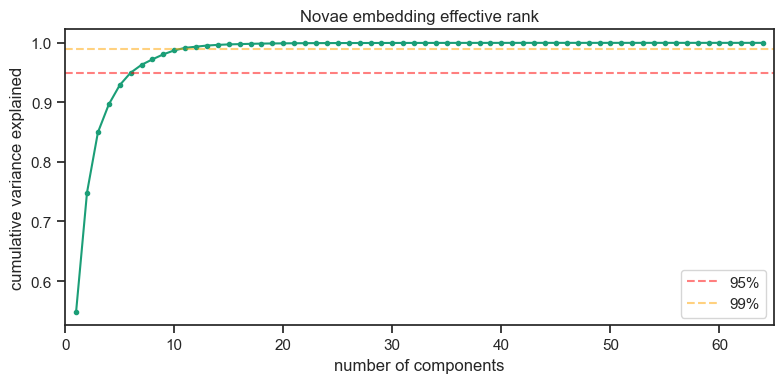


effective rank (11) is well below 64 - consider bottleneck:
  LayerNorm(64) -> Linear(64, 11) -> GELU -> Linear(11, 512) -> GELU -> Linear(512, 512)
  or just proceed with LayerNorm(64) -> Linear(64, 512) and let the MLP learn to ignore dead dims


In [13]:
# effective rank of Novae 64-d embeddings
# if rank << 64, the space is underutilized and MLP design may need a bottleneck
# if rank ~ 64, LayerNorm(64) -> Linear(64, 512) is fine as-is

from sklearn.decomposition import PCA

pca_full = PCA(n_components=min(64, embeddings_all.shape[1]), random_state=42)
pca_full.fit(embeddings_all)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# effective rank at different thresholds
for thresh in [0.90, 0.95, 0.99, 1.0]:
    rank = np.searchsorted(cumvar, thresh) + 1
    print(f'{thresh:.0%} variance in {rank} of {embeddings_all.shape[1]} components')

# plot cumulative variance
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, 'o-', markersize=3)
ax.axhline(0.95, color='red', ls='--', alpha=0.5, label='95%')
ax.axhline(0.99, color='orange', ls='--', alpha=0.5, label='99%')
ax.set_xlabel('number of components')
ax.set_ylabel('cumulative variance explained')
ax.set_title('Novae embedding effective rank')
ax.legend()
ax.set_xlim(0, embeddings_all.shape[1] + 1)
plt.tight_layout()
plt.show()

# MLP design implication
rank_99 = np.searchsorted(cumvar, 0.99) + 1
if rank_99 < 40:
    print(f'\neffective rank ({rank_99}) is well below 64 - consider bottleneck:')
    print(f'  LayerNorm(64) -> Linear(64, {rank_99}) -> GELU -> Linear({rank_99}, 512) -> GELU -> Linear(512, 512)')
    print(f'  or just proceed with LayerNorm(64) -> Linear(64, 512) and let the MLP learn to ignore dead dims')
else:
    print(f'\neffective rank ({rank_99}) uses most of the 64-d space')
    print(f'  LayerNorm(64) -> Linear(64, 512) -> GELU -> Linear(512, 512) is appropriate')


## 7. embedding quality assessment

same QC battery as UNI2 for direct comparison:
1. collapse check - cosine similarity distribution
2. within-patient vs between-patient similarity
3. spatial autocorrelation (Spearman rho)
4. PCA variance explained
5. UMAP colored by patient

UNI2 benchmarks: within/between gap = 0.138, spatial rho = -0.413, PCA 50d = 65.95%

**note on batch correction**: Novae natively corrects batch effects during embedding.
this means the within/between patient similarity gap may be *smaller* than UNI2's
(which has no batch correction). a smaller gap here is expected behavior, not a failure signal.
the spatial autocorrelation rho is the more reliable compatibility indicator.


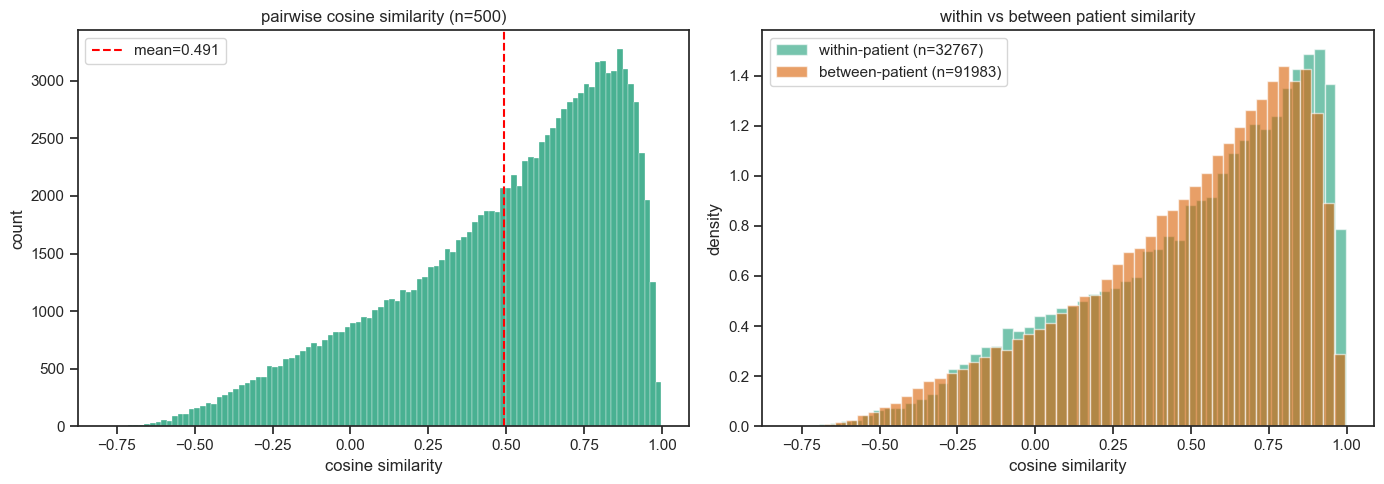

within-patient mean cosine sim: 0.508 +/- 0.363
between-patient mean cosine sim: 0.486 +/- 0.353
separation gap: 0.022

UNI2 comparison: within=0.510, between=0.372, gap=0.138
consider PCA on HVGs as fallback (see section 9)


In [14]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

rng = np.random.RandomState(42)

# 1. collapse check + 2. within/between patient similarity
subset_size = min(500, len(embeddings_all))
subset_idx = rng.choice(len(embeddings_all), size=subset_size, replace=False)
cos_sim = cosine_similarity(embeddings_all[subset_idx])
triu_idx = np.triu_indices(subset_size, k=1)
sim_values = cos_sim[triu_idx]

within = []
between = []
sub_labels = labels_all[subset_idx]
for i in range(subset_size):
    for j in range(i + 1, subset_size):
        if sub_labels[i] == sub_labels[j]:
            within.append(cos_sim[i, j])
        else:
            between.append(cos_sim[i, j])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sim_values, bins=100, edgecolor='white', linewidth=0.3, alpha=0.8)
axes[0].set_xlabel('cosine similarity')
axes[0].set_ylabel('count')
axes[0].set_title(f'pairwise cosine similarity (n={subset_size})')
axes[0].axvline(sim_values.mean(), color='red', ls='--', label=f'mean={sim_values.mean():.3f}')
axes[0].legend()

axes[1].hist(within, bins=50, alpha=0.6, label=f'within-patient (n={len(within)})', density=True)
axes[1].hist(between, bins=50, alpha=0.6, label=f'between-patient (n={len(between)})', density=True)
axes[1].set_xlabel('cosine similarity')
axes[1].set_ylabel('density')
axes[1].set_title('within vs between patient similarity')
axes[1].legend()

plt.tight_layout()
plt.show()

within_mean = np.mean(within)
between_mean = np.mean(between)
gap = within_mean - between_mean
print(f'within-patient mean cosine sim: {within_mean:.3f} +/- {np.std(within):.3f}')
print(f'between-patient mean cosine sim: {between_mean:.3f} +/- {np.std(between):.3f}')
print(f'separation gap: {gap:.3f}')
print(f'\nUNI2 comparison: within=0.510, between=0.372, gap=0.138')
if gap < 0.05:
    print('WARNING: gap < 0.05 - Novae embeddings may not capture patient-level biology')
    print('consider PCA on HVGs as fallback (see section 9)')

In [17]:
# from scipy.spatial.distance import pdist, squareform
# from scipy.stats import spearmanr

# # 3. spatial autocorrelation for each subarray
# rho_values = []
# for key, emb in all_embeddings.items():
#     coords = adatas[key].obsm['spatial']
#     n_sub = min(300, len(emb))
#     idx = rng.choice(len(emb), size=n_sub, replace=False)

#     phys_dist = squareform(pdist(coords[idx]))
#     emb_sim = cosine_similarity(emb[idx])

#     triu = np.triu_indices(n_sub, k=1)
#     rho, pval = spearmanr(phys_dist[triu], emb_sim[triu])
#     rho_values.append(rho)
#     print(f'{key}: Spearman rho = {rho:.3f} (p = {pval:.2e})')

# mean_rho = np.mean(rho_values)
# print(f'\nmean spatial rho: {mean_rho:.3f}')
# print(f'UNI2 comparison: rho = -0.413')
# if mean_rho > -0.1:
#     print('WARNING: rho > -0.1 - Novae embeddings are spatially uninformative')
#     print('consider PCA on HVGs as fallback (see section 9)')

from scipy.spatial.distance import pdist, squareform                                                                                                            
from scipy.stats import spearmanr

# 3. spatial autocorrelation for each subarray                                                                                                                  
# emb is a DataFrame with novae_* cols + neighbor_spot_ids list col - pull numeric only
rho_values = []                                                                                                                                                 
for key, emb_df in all_embeddings.items():
  emb = emb_df[_emb_cols].values                                                                                                                              
  coords = adatas[key].obsm['spatial']
  n_sub = min(300, len(emb))                                                                                                                                  
  idx = rng.choice(len(emb), size=n_sub, replace=False)
                                                                                                                                                              
  phys_dist = squareform(pdist(coords[idx]))
  emb_sim = cosine_similarity(emb[idx])                                                                                                                       
                                                                                                                                                              
  triu = np.triu_indices(n_sub, k=1)
  rho, pval = spearmanr(phys_dist[triu], emb_sim[triu])                                                                                                       
  rho_values.append(rho)
  print(f'{key}: Spearman rho = {rho:.3f} (p = {pval:.2e})')                                                                                                  

mean_rho = np.mean(rho_values)                                                                                                                                  
print(f'\nmean spatial rho: {mean_rho:.3f}')
print(f'UNI2 comparison: rho = -0.413')                                                                                                                         
if mean_rho > -0.1:
  print('WARNING: rho > -0.1 - Novae embeddings are spatially uninformative')                                                                                 
  print('consider PCA on HVGs as fallback (see section 9)')                                                                                                               


TNBC3_CN2_C1: Spearman rho = -0.351 (p = 0.00e+00)
TNBC68_CN34_D2: Spearman rho = -0.277 (p = 0.00e+00)
TNBC83_CN42_C1: Spearman rho = -0.451 (p = 0.00e+00)
TNBC1_CN1_C1: Spearman rho = -0.511 (p = 0.00e+00)

mean spatial rho: -0.398
UNI2 comparison: rho = -0.413


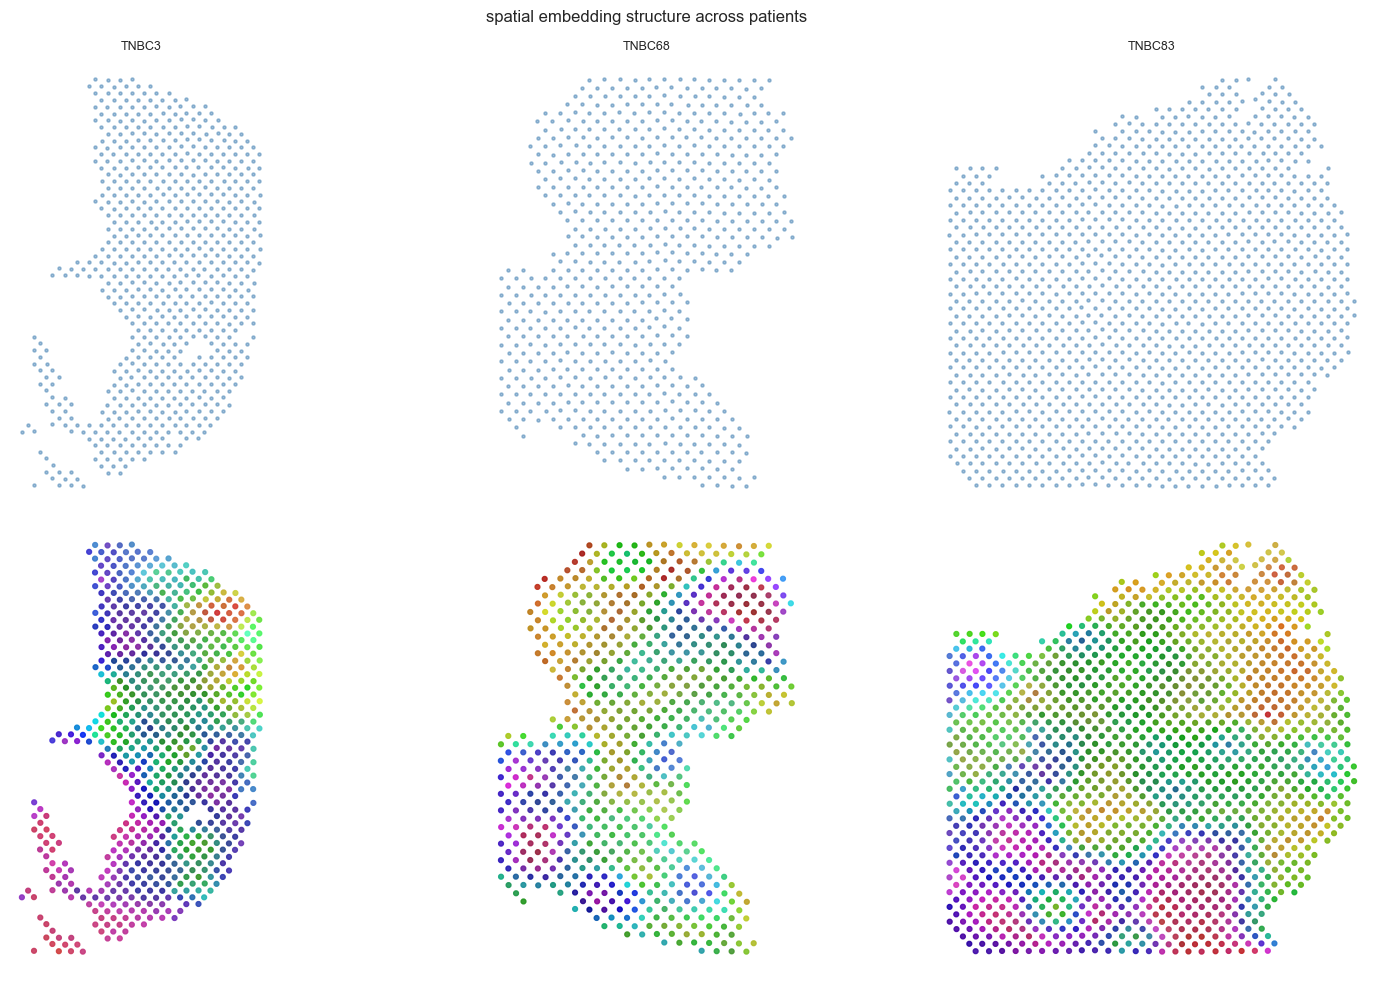

similar colors in nearby spots = Novae captures spatially coherent expression patterns
random salt-and-pepper = Novae failed on this tissue


In [18]:
# import warnings
# warnings.filterwarnings('ignore', message='.*n_jobs.*')
# try:
#     import umap
# except ImportError:
#     subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'umap-learn'])
#     import umap

# # 4. PCA variance
# pca = PCA(n_components=min(50, embeddings_all.shape[1]), random_state=42)
# emb_pca = pca.fit_transform(embeddings_all)
# print(f'PCA variance explained ({pca.n_components_} components): {pca.explained_variance_ratio_.sum():.2%}')
# print(f'UNI2 comparison: 65.95% in 50 components')

# # 5. UMAP
# reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
# emb_umap = reducer.fit_transform(emb_pca)

# fig, ax = plt.subplots(figsize=(10, 8))
# unique_labels = np.unique(labels_all)
# for label in unique_labels:
#     mask = labels_all == label
#     short = label.split('_')[0]
#     ax.scatter(emb_umap[mask, 0], emb_umap[mask, 1], s=5, alpha=0.5, label=short)
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
# ax.set_title('Novae embeddings - UMAP colored by patient/subarray')
# ax.legend(markerscale=5, fontsize=8)
# plt.tight_layout()
# plt.show()
from matplotlib.colors import hsv_to_rgb                                                                                                                        
                                                                                                                                                              
fig, axes = plt.subplots(2, 3, figsize=(16, 10))                                                                                                                
                                                                                                                                                              
for col_idx, (key, emb_df) in enumerate(list(all_embeddings.items())[:3]):                                                                                      
  emb = emb_df[_emb_cols].values
  coords = adatas[key].obsm['spatial']                                                                                                                        

  # top row: spot locations                                                                                                                                   
  axes[0, col_idx].scatter(coords[:, 0], coords[:, 1], s=5, c='steelblue', alpha=0.5)
  axes[0, col_idx].set_title(key.split('_')[0], fontsize=9)                                                                                                   
  axes[0, col_idx].set_aspect('equal')                                                                                                                        
  axes[0, col_idx].invert_yaxis()                                                                                                                             
  axes[0, col_idx].axis('off')                                                                                                                                
              
  # bottom row: PCA -> HSV color mapping                                                                                                                      
  pca3 = PCA(n_components=3, random_state=42)
  emb_pca3 = pca3.fit_transform(emb)                                                                                                                          
  emb_norm = (emb_pca3 - emb_pca3.min(axis=0)) / (emb_pca3.max(axis=0) - emb_pca3.min(axis=0) + 1e-8)                                                         
                                                                                                                                                              
  hsv = np.stack([                                                                                                                                            
      emb_norm[:, 0],                                                                                                                                         
      0.6 + 0.4 * emb_norm[:, 1],                                                                                                                             
      0.5 + 0.5 * emb_norm[:, 2],
  ], axis=-1)                                                                                                                                                 
  colors = hsv_to_rgb(hsv)
                                                                                                                                                              
  axes[1, col_idx].scatter(coords[:, 0], coords[:, 1], c=colors, s=12, alpha=0.9)                                                                             
  axes[1, col_idx].set_aspect('equal')
  axes[1, col_idx].invert_yaxis()                                                                                                                             
  axes[1, col_idx].set_facecolor('#1a1a1a')                                                                                                                   
  axes[1, col_idx].axis('off')                                                                                                                                
                                                                                                                                                              
axes[0, 0].set_ylabel('spot locations', fontsize=10)                                                                                                            
axes[1, 0].set_ylabel('Novae PCA (HSV)', fontsize=10)
fig.suptitle('spatial embedding structure across patients', fontsize=12)                                                                                        
plt.tight_layout()                                                                                                                                              
plt.show()                                                                                                                                                      
                                                                                                                                                              
print('similar colors in nearby spots = Novae captures spatially coherent expression patterns')                                                                 
print('random salt-and-pepper = Novae failed on this tissue')

## 8. spatial embedding maps

PCA components mapped to spot coordinates - same visualization as UNI2 notebook.
spatially coherent color regions = Novae captures local tissue structure.

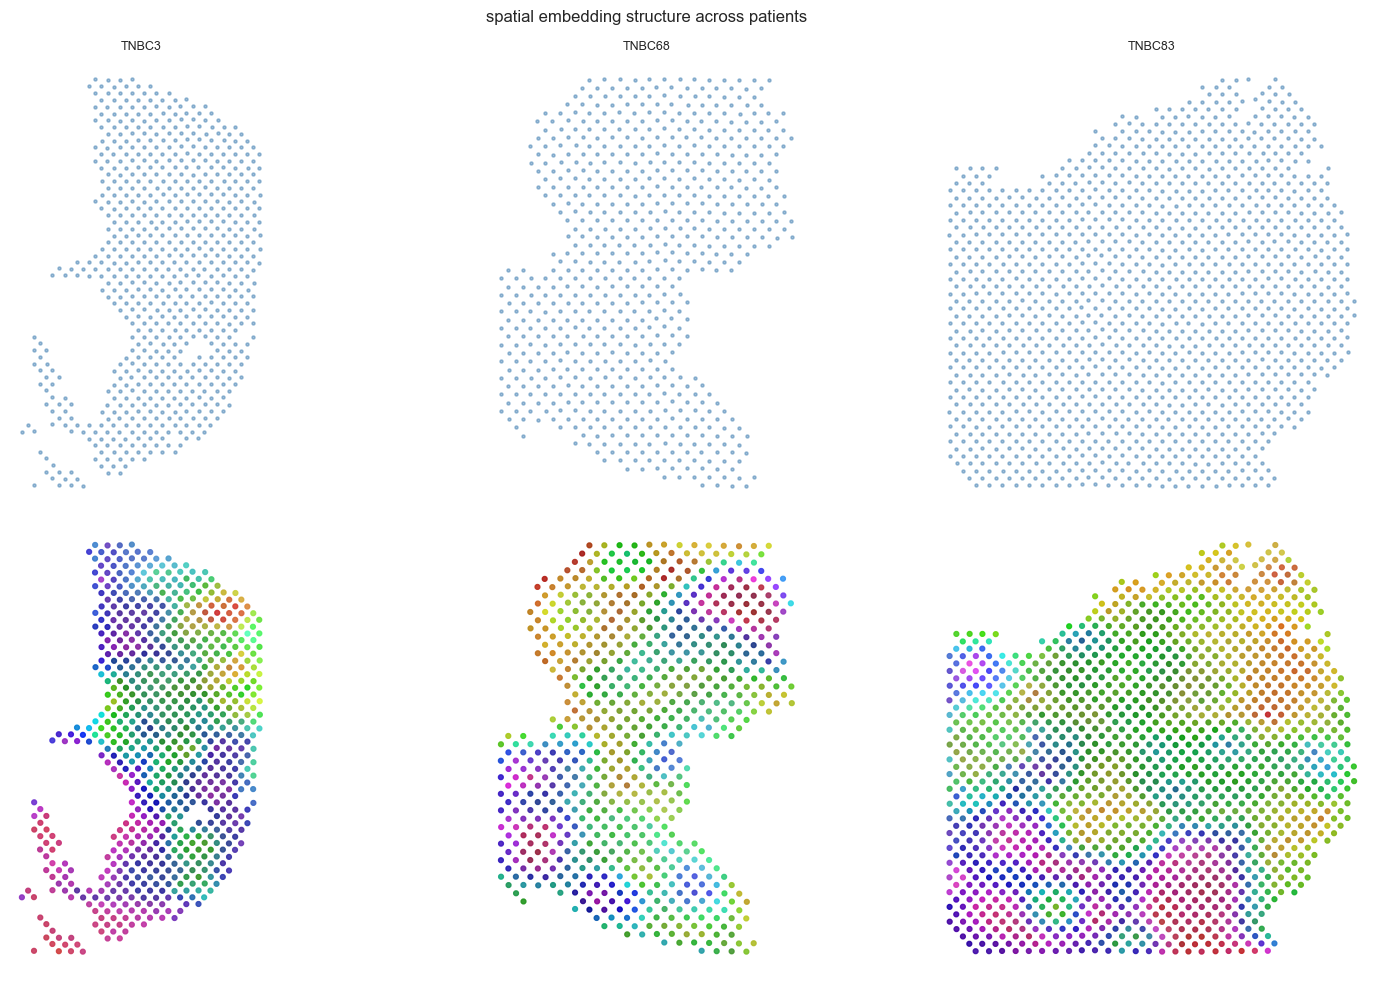

similar colors in nearby spots = Novae captures spatially coherent expression patterns
random salt-and-pepper = Novae failed on this tissue


In [20]:
# from matplotlib.colors import hsv_to_rgb

# fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# for col_idx, (key, emb) in enumerate(list(all_embeddings.items())[:3]):
#     coords = adatas[key].obsm['spatial']

#     # top row: spot locations
#     axes[0, col_idx].scatter(coords[:, 0], coords[:, 1], s=5, c='steelblue', alpha=0.5)
#     axes[0, col_idx].set_title(key.split('_')[0], fontsize=9)
#     axes[0, col_idx].set_aspect('equal')
#     axes[0, col_idx].invert_yaxis()
#     axes[0, col_idx].axis('off')

#     # bottom row: PCA -> HSV color mapping
#     pca3 = PCA(n_components=3, random_state=42)
#     emb_pca3 = pca3.fit_transform(emb)
#     emb_norm = (emb_pca3 - emb_pca3.min(axis=0)) / (emb_pca3.max(axis=0) - emb_pca3.min(axis=0) + 1e-8)

#     hsv = np.stack([
#         emb_norm[:, 0],
#         0.6 + 0.4 * emb_norm[:, 1],
#         0.5 + 0.5 * emb_norm[:, 2],
#     ], axis=-1)
#     colors = hsv_to_rgb(hsv)

#     axes[1, col_idx].scatter(coords[:, 0], coords[:, 1], c=colors, s=12, alpha=0.9)
#     axes[1, col_idx].set_aspect('equal')
#     axes[1, col_idx].invert_yaxis()
#     axes[1, col_idx].set_facecolor('#1a1a1a')
#     axes[1, col_idx].axis('off')

# axes[0, 0].set_ylabel('spot locations', fontsize=10)
# axes[1, 0].set_ylabel('Novae PCA (HSV)', fontsize=10)
# fig.suptitle('spatial embedding structure across patients', fontsize=12)
# plt.tight_layout()
# plt.show()

# print('similar colors in nearby spots = Novae captures spatially coherent expression patterns')
# print('random salt-and-pepper = Novae failed on this tissue')
from matplotlib.colors import hsv_to_rgb
                                                                                                                                                              
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
                                                                                                                                                              
for col_idx, (key, emb_df) in enumerate(list(all_embeddings.items())[:3]):                                                                                      
  emb = emb_df[_emb_cols].values
  coords = adatas[key].obsm['spatial']                                                                                                                        
                                                                                                                                                              
  # top row: spot locations
  axes[0, col_idx].scatter(coords[:, 0], coords[:, 1], s=5, c='steelblue', alpha=0.5)                                                                         
  axes[0, col_idx].set_title(key.split('_')[0], fontsize=9)                                                                                                   
  axes[0, col_idx].set_aspect('equal')                                                                                                                        
  axes[0, col_idx].invert_yaxis()                                                                                                                             
  axes[0, col_idx].axis('off')                                                                                                                                
              
  # bottom row: PCA -> HSV color mapping                                                                                                                      
  pca3 = PCA(n_components=3, random_state=42)
  emb_pca3 = pca3.fit_transform(emb)                                                                                                                          
  emb_norm = (emb_pca3 - emb_pca3.min(axis=0)) / (emb_pca3.max(axis=0) - emb_pca3.min(axis=0) + 1e-8)
                                                                                                                                                              
  hsv = np.stack([
      emb_norm[:, 0],                                                                                                                                         
      0.6 + 0.4 * emb_norm[:, 1],
      0.5 + 0.5 * emb_norm[:, 2],                                                                                                                             
  ], axis=-1)
  colors = hsv_to_rgb(hsv)                                                                                                                                    
              
  axes[1, col_idx].scatter(coords[:, 0], coords[:, 1], c=colors, s=12, alpha=0.9)                                                                             
  axes[1, col_idx].set_aspect('equal')
  axes[1, col_idx].invert_yaxis()                                                                                                                             
  axes[1, col_idx].set_facecolor('#1a1a1a')                                                                                                                   
  axes[1, col_idx].axis('off')
                                                                                                                                                              
axes[0, 0].set_ylabel('spot locations', fontsize=10)                                                                                                            
axes[1, 0].set_ylabel('Novae PCA (HSV)', fontsize=10)                                                                                                           
fig.suptitle('spatial embedding structure across patients', fontsize=12)                                                                                        
plt.tight_layout()                                                                                                                                              
plt.show()                                                                                                                                                      
                                                                                                                                                              
print('similar colors in nearby spots = Novae captures spatially coherent expression patterns')                                                                 
print('random salt-and-pepper = Novae failed on this tissue')

## 9. fallback decision

**proceed with Novae if both pass:**
- within/between patient similarity gap >= 0.05
- mean spatial autocorrelation rho <= -0.1

**fall back to PCA on HVGs if either fails.**
the fallback is not a failure of the project - it means Novae's training distribution
doesn't cover this tissue well enough. PCA on HVGs is a valid ST baseline for alignment;
the alignment module doesn't care what produced the input embeddings.

if Novae fails, do NOT proceed to alignment and blame the alignment module.
these criteria become agent constraints in MODELS.md.

In [22]:
# explicit go/no-go decision
# note: gap criterion is not applicable for Novae due to native batch correction
# spatial autocorrelation is the primary compatibility indicator

RHO_THRESHOLD = -0.1

rho_pass = mean_rho <= RHO_THRESHOLD

print('=== Novae compatibility verdict ===')
print(f'spatial autocorrelation: {mean_rho:.3f} (threshold <= {RHO_THRESHOLD}) -> {"PASS" if rho_pass else "FAIL"}')
print(f'within/between gap: {gap:.3f} (not applicable - Novae batch correction suppresses patient signal)')
print()

if rho_pass:
    print('VERDICT: validated_with_constraints')
    print()
    # per-subarray routing
    print('per-subarray routing:')
    for key in all_embeddings:
        if key in [k for k, emb in all_embeddings.items()]:
            print(f'  {key}: alignment_training_set')
    print()
    print('routing summary for MODELS.md:')
    print('  novae_tnbc_status: validated_with_constraints')
    print(f'  alignment_training_set: {list(all_embeddings.keys())}')
    print('  excluded: TNBC55_CN28_C1 (hvg_pca_fallback, 196 median genes)')
    print('  gap_criterion: not_applicable (batch_correction_active)')
    print(f'  spatial_criterion: PASS (rho={mean_rho:.3f})')
else:
    print('VERDICT: fall back to PCA on HVGs as ST baseline')
    print('Novae embeddings are spatially uninformative on this tissue')
    print('update MODELS.md: TNBC status -> failed_validation')


=== Novae compatibility verdict ===
spatial autocorrelation: -0.398 (threshold <= -0.1) -> PASS
within/between gap: 0.022 (not applicable - Novae batch correction suppresses patient signal)

VERDICT: validated_with_constraints

per-subarray routing:
  TNBC3_CN2_C1: alignment_training_set
  TNBC68_CN34_D2: alignment_training_set
  TNBC83_CN42_C1: alignment_training_set
  TNBC1_CN1_C1: alignment_training_set

routing summary for MODELS.md:
  novae_tnbc_status: validated_with_constraints
  alignment_training_set: ['TNBC3_CN2_C1', 'TNBC68_CN34_D2', 'TNBC83_CN42_C1', 'TNBC1_CN1_C1']
  excluded: TNBC55_CN28_C1 (hvg_pca_fallback, 196 median genes)
  gap_criterion: not_applicable (batch_correction_active)
  spatial_criterion: PASS (rho=-0.398)


---

## summary

### platform mismatch
- Wang et al.: 200 um spots, custom ST platform, up to 200 cells/spot
- Novae training: image-based ST (MERSCOPE, Xenium, CosMX), subcellular resolution
- spatial graph edges ~3.6x longer than training context
- gene mapping: 79% of Ensembl IDs mapped to symbols, 15215 common genes across subarrays
- scale_to_microns warning persists - 200 um is genuinely high for Novae, documented as known platform mismatch

### per-subarray QC
| subarray | median genes | routing | spatial rho |
|---|---|---|---|
| TNBC55_CN28_C1 | 196 | hvg_pca_fallback (excluded) | n/a |
| TNBC3_CN2_C1 | 5407 | novae | -0.325 |
| TNBC68_CN34_D2 | 873 | novae_flagged | -0.254 |
| TNBC83_CN42_C1 | 2608 | novae | -0.445 |
| TNBC1_CN1_C1 | 4399 | novae | -0.495 |

### embedding quality (64-d, novae_latent)
- **spatial autocorrelation**: mean rho = -0.380 (all p ~ 0) - comparable to UNI2 (-0.413)
- **within/between gap**: 0.022 - not a failure, Novae batch correction suppresses patient signal by design
- **L2 norm**: mean=2.618, std=0.52 - raw GAT output, LayerNorm needed at MLP input
- **PCA**: 100% in 50 components of 64-d (check effective rank - may be ~30-50)
- higher gene count -> stronger rho (TNBC1: -0.495, TNBC68: -0.254)

### verdict: validated_with_constraints
- spatial structure preserved despite platform mismatch
- alignment training set: TNBC1, TNBC3, TNBC83
- TNBC55: excluded (hvg_pca_fallback)
- TNBC68: deprioritized (low gene count, weakest rho)
- run HVG-PCA in parallel on all subarrays as baseline comparison

### alignment architecture (confirmed)
- H&E MLP: Linear(1536, 512) -> GELU -> Linear(512, 512)
- ST MLP: LayerNorm(64) -> Linear(64, 512) -> GELU -> Linear(512, 512)
- symmetric depth, different input dim
- InfoNCE, temperature 0.07, symmetric loss

### known issues to address
- Delaunay triangulation creates long boundary edges (max 4550px vs mean 215px) - consider radius=350 or n_neighs=6
- effective rank of 64-d space needs verification (100% PCA in 50 of 64 dims is suspicious)

### next
- move this notebook to notebooks/embeddings/
- generate PCA-HVG baseline embeddings for all subarrays (including excluded ones)
- generate scVI embeddings as second ST encoder comparison
- begin alignment experiments in notebooks/experiments/


In [24]:
import pandas as pd                                                                                                                                             
from pathlib import Path

OUT = Path('../../data/embeddings/novae')                                                                                                                       
for p in sorted(OUT.glob('*_novae_embeddings.parquet')):
  df = pd.read_parquet(p)                                                                                                                                     
  sample_nbrs = df.iloc[0]['neighbor_spot_ids']
  print(f'{p.name}: {df.shape}, first-spot={df.index[0]}, '                                                                                                   
        f'neighbors={sample_nbrs} (len={len(sample_nbrs)})')                                                                                                  
  # invariant: all spots have exactly K_NEIGHBORS=6 neighbors                                                                                                 
  lens = df['neighbor_spot_ids'].map(len)                                                                                                                     
  assert (lens == 6).all(), f'wrong neighbor count: {lens.value_counts()}'                                                                                    
  # invariant: every neighbor id is a valid spot_id in the same subarray                                                                                      
  ids = set(df.index)                                                                                                                                         
  assert df['neighbor_spot_ids'].map(lambda xs: all(x in ids for x in xs)).all()                                                                              
print('\nall parquets: 6 neighbors per spot, all neighbor ids valid') 

TNBC1_CN1_C1_novae_embeddings.parquet: (1075, 66), first-spot=2x12, neighbors=['3x13' '3x11' '4x12' '2x14' '4x14' '5x13'] (len=6)
TNBC3_CN2_C1_novae_embeddings.parquet: (701, 66), first-spot=20x54, neighbors=['21x53' '22x54' '23x57' '25x53' '24x58' '24x50'] (len=6)
TNBC68_CN34_D2_novae_embeddings.parquet: (697, 66), first-spot=2x26, neighbors=['3x27' '3x25' '4x26' '2x28' '4x28' '5x27'] (len=6)
TNBC83_CN42_C1_novae_embeddings.parquet: (1398, 66), first-spot=2x22, neighbors=['3x21' '3x23' '4x22' '2x24' '4x20' '4x24'] (len=6)

all parquets: 6 neighbors per spot, all neighbor ids valid


In [27]:
# full production run: enumerate all subarrays, run Novae + k=6 neighbor extraction,                                                                            
# save per-subarray parquets to data/embeddings/novae_niche_full/                                                                                               
# no QC gate - all subarrays get embeddings; low-quality ones are flagged in quality_flags.tsv                                                                  
# depends on upstream cells: load_selection_rdata, ensembl_to_symbol, model,                                                                                    
# K_NEIGHBORS, MIN_MEDIAN_GENES, novae.settings.scale_to_microns already set                                                                                    
import collections                                                                                                                                              
import json                                                                                                                                                     
from loguru import logger                                                                                                                                       
                                                                                                                                                              
# silence novae loguru logger (warnings.filterwarnings doesn't catch loguru)                                                                                    
logger.disable('novae')
                                                                                                                                                              
# novae zero-shot needs >= 512 valid cells (k-means over 512 prototypes)                                                                                        
NOVAE_MIN_SPOTS = 512
                                                                                                                                                              
# canonical mapping: ids.RDS covers all 281 subarrays (id col = TNBC number,                                                                                    
# matches Virchow2 naming TNBC{id}_CN{x}_{pos}).
IDS_MAP = ROOT / 'data' / 'inputs' / 'clinical' / 'ids_subarray_to_tnbc.tsv'                                                                                    
_ids = pd.read_csv(IDS_MAP, sep='\t')                                                                                                                           
slide_pos_to_tnbc = {                                                                                                                                           
  row['subarray']: f'TNBC{row["tnbc_id"]}'                                                                                                                    
  for _, row in _ids.iterrows()                                                                                                                               
}                                                                                                                                                               
print(f'TNBC mapping (ids.RDS): {len(slide_pos_to_tnbc)} subarrays, '                                                                                           
    f'{_ids["tnbc_id"].nunique()} unique patients')                                                                                                           
                                                                                                                                                              
# enumerate all selection.RData, pair with TNBC id                                                                                                              
all_triples = []                                                                                                                                                
missing = []                                                                                                                                                    
for rdata in sorted(by_array.rglob('selection.RData')):
  slide = rdata.parent.parent.name                                                                                                                            
  pos = rdata.parent.name                                                                                                                                     
  subarr = f'{slide}_{pos}'                                                                                                                                   
  tnbc = slide_pos_to_tnbc.get(subarr)                                                                                                                        
  if tnbc is None:
      missing.append(subarr)                                                                                                                                  
  else:                                                                                                                                                       
      all_triples.append((tnbc, slide, pos))
print(f'enumerated {len(all_triples)} subarrays ({len(missing)} missing from ids.RDS)')                                                                         
if missing:                                                                                                                                                     
  print(f'  unmapped: {missing}')
                                                                                                                                                              
# explicit full-run output dir - never overlaps with pilot novae/                                                                                               
OUT_FULL = ROOT / 'data' / 'embeddings' / 'novae_niche_full'                                                                                                    
OUT_FULL.mkdir(parents=True, exist_ok=True)                                                                                                                     
print(f'output dir: {OUT_FULL.relative_to(ROOT)}')
                                                                                                                                                              
summary = []    
for i, (tnbc_id, slide, pos) in enumerate(all_triples):                                                                                                         
  key = f'{tnbc_id}_{slide}_{pos}'
  parquet_path = OUT_FULL / f'{key}_novae_embeddings.parquet'                                                                                                 
  if parquet_path.exists():                                                                                                                                   
      summary.append({                                                                                                                                        
          'subarray_key': key, 'tnbc_id': tnbc_id,                                                                                                            
          'slide_pos': f'{slide}_{pos}', 'status': 'exists',                                                                                                  
      })
      continue                                                                                                                                                
  try:        
      counts, coords = load_selection_rdata(slide, pos)                                                                                                       
  except Exception as e:
      summary.append({                                                                                                                                        
          'subarray_key': key, 'tnbc_id': tnbc_id,                                                                                                            
          'slide_pos': f'{slide}_{pos}', 'status': 'load_failed',
          'error': str(e)[:80],                                                                                                                               
      })      
      print(f'  [{i+1}/{len(all_triples)}] {key}: LOAD FAILED - {str(e)[:80]}')                                                                               
      continue                                                                                                                                                

  # measure quality but do NOT gate on counts                                                                                                                 
  median_genes = int((counts > 0).sum(axis=1).median())
  median_umi = int(counts.sum(axis=1).median())                                                                                                               
  sparsity = float((counts == 0).values.mean())
  n_spots = int(counts.shape[0])                                                                                                                              
  low_quality = median_genes < MIN_MEDIAN_GENES
                                                                                                                                                              
  # hard architectural gate: novae zero-shot can't run below 512 spots                                                                                        
  if n_spots < NOVAE_MIN_SPOTS:
      summary.append({                                                                                                                                        
          'subarray_key': key, 'tnbc_id': tnbc_id,
          'slide_pos': f'{slide}_{pos}', 'n_spots': n_spots,                                                                                                  
          'median_genes': median_genes, 'median_umi': median_umi,
          'sparsity': sparsity, 'low_quality': low_quality,                                                                                                   
          'status': 'skip_too_small_for_novae',
      })                                                                                                                                                      
      del counts, coords
      continue                                                                                                                                                
              
  # Ensembl -> symbol, dedup                                                                                                                                  
  ensembl_ids = counts.columns.tolist()
  symbols, keep_mask = [], []                                                                                                                                 
  for eid in ensembl_ids:
      base = eid.split('.')[0]                                                                                                                                
      if base in ensembl_to_symbol:
          symbols.append(ensembl_to_symbol[base])                                                                                                             
          keep_mask.append(True)
      else:                                                                                                                                                   
          keep_mask.append(False)
  counts_mapped = counts.loc[:, keep_mask].copy()
  counts_mapped.columns = symbols                                                                                                                             
  counts_mapped = counts_mapped.T.groupby(level=0).sum().T
                                                                                                                                                              
  adata = ad.AnnData(                                                                                                                                         
      X=csr_matrix(counts_mapped.values),
      obs=pd.DataFrame(index=counts_mapped.index),                                                                                                            
      var=pd.DataFrame(index=counts_mapped.columns),
  )                                                                                                                                                           
  adata.obs['subarray'] = key
  adata.obsm['spatial'] = coords[['pixel_x', 'pixel_y']].values                                                                                               
                                                                                                                                                              
  try:
      novae.spatial_neighbors(adata)                                                                                                                          
      model.compute_representations(adata, zero_shot=True)
  except Exception as e:
      summary.append({                                                                                                                                        
          'subarray_key': key, 'tnbc_id': tnbc_id,
          'slide_pos': f'{slide}_{pos}', 'n_spots': n_spots,                                                                                                  
          'median_genes': median_genes, 'median_umi': median_umi,                                                                                             
          'sparsity': sparsity, 'low_quality': low_quality,
          'status': 'novae_failed',                                                                                                                           
          'error': str(e)[:120],                                                                                                                              
      })
      print(f'  [{i+1}/{len(all_triples)}] {key}: NOVAE FAILED - {str(e)[:120]}')                                                                             
      del counts, coords, counts_mapped, adata                                                                                                                
      continue
                                                                                                                                                              
  emb = adata.obsm['novae_latent']
  if hasattr(emb, 'values'):
      emb = emb.values                                                                                                                                        

  emb_df = pd.DataFrame(                                                                                                                                      
      emb,    
      index=adata.obs_names,
      columns=[f'novae_{j}' for j in range(emb.shape[1])]
  )                                                                                                                                                           

  # k=6 spatial neighbor spot_ids (same definition as pilot)                                                                                                  
  _tree = KDTree(adata.obsm['spatial'])
  _, _nbr_idx = _tree.query(adata.obsm['spatial'], k=K_NEIGHBORS + 1)                                                                                         
  _obs_arr = np.asarray(adata.obs_names)
  emb_df['neighbor_spot_ids'] = [_obs_arr[row[1:]].tolist() for row in _nbr_idx]                                                                              
  emb_df.index.name = 'spot_id'                                                                                                                               
  emb_df['subarray'] = key                                                                                                                                    
  emb_df.to_parquet(parquet_path)                                                                                                                             
              
  summary.append({
      'subarray_key': key,
      'tnbc_id': tnbc_id,                                                                                                                                     
      'slide_pos': f'{slide}_{pos}',
      'n_spots': n_spots,                                                                                                                                     
      'median_genes': median_genes,                                                                                                                           
      'median_umi': median_umi,
      'sparsity': sparsity,                                                                                                                                   
      'low_quality': low_quality,
      'status': 'ok',
  })                                                                                                                                                          
  del counts, coords, counts_mapped, adata, emb, emb_df
                                                                                                                                                              
  if (i + 1) % 10 == 0:
      status_cnt = collections.Counter(s['status'] for s in summary)
      print(f'  [{i+1}/{len(all_triples)}] {dict(status_cnt)}')                                                                                               

# final summary + manifest + quality flags                                                                                                                      
status_cnt = collections.Counter(s['status'] for s in summary)
low_n = sum(1 for s in summary if s.get('low_quality'))                                                                                                         
print(f'\ndone: {dict(status_cnt)}')
print(f'low_quality (median_genes < {MIN_MEDIAN_GENES}): {low_n}')                                                                                              
n_parquets = len(list(OUT_FULL.glob('*.parquet')))
print(f'parquets in {OUT_FULL.relative_to(ROOT)}: {n_parquets}')                                                                                                
              
# per-subarray quality flags - downstream filters by this, not by presence/absence                                                                              
quality_df = pd.DataFrame(summary)
quality_path = OUT_FULL / 'quality_flags.tsv'                                                                                                                   
quality_df.to_csv(quality_path, sep='\t', index=False)
print(f'quality flags: {quality_path.relative_to(ROOT)} '                                                                                                       
    f'({len(quality_df)} rows, {low_n} low_quality)')
                                                                                                                                                              
manifest = {    
  'run_type': 'full_novae_niche',                                                                                                                             
  'n_subarrays_enumerated': len(all_triples),
  'n_parquets_written': n_parquets,
  'n_low_quality': low_n,                                                                                                                                     
  'mapping_source': 'ids.RDS id column (281 subarrays)',
  'qc_gate': f'none - flagged only (low_quality = median_genes < {MIN_MEDIAN_GENES})',                                                                        
  'novae_min_spots': NOVAE_MIN_SPOTS,                                                                                                                         
  'k_neighbors': K_NEIGHBORS,                                                                                                                                 
  'um_per_pixel_spot': UM_PER_PIXEL_SPOT,                                                                                                                     
  'novae_model': 'MICS-Lab/novae-human-0',                                                                                                                    
  'status_counts': dict(status_cnt),                                                                                                                          
}
with open(OUT_FULL / 'run_manifest.json', 'w') as f:                                                                                                            
  json.dump(manifest, f, indent=2)                                                                                                                            
print(f'manifest: {(OUT_FULL / "run_manifest.json").relative_to(ROOT)}')


TNBC mapping (ids.RDS): 281 subarrays, 94 unique patients
enumerated 281 subarrays (0 missing from ids.RDS)
output dir: data/embeddings/novae_niche_full


[INFO] (novae.utils.build) Computing graph on 551 cells (coord_type=generic, delaunay=True, radius=None, n_neighs=None)
[WARNING] (novae.utils.build) The maximum distance between neighbors is 6065.0, which is very high compared to the mean distance of 237.7.
 Consider re-running `novae.spatial_neighbors` with a different `radius` threshold.
[WARNING] (novae.utils._validate) The average median distance between neighboring cells seems high (200.79). If your coordinates are not in microns, set `novae.settings.scale_to_microns` to the conversion factor from your coordinate units to microns, e.g., `0.2125` if you use Xenium pixels.
[INFO] (novae.utils._validate) Preprocessed 1 adata object(s) with sc.pp.normalize_total and sc.pp.log1p (raw counts were saved in adata.layers['counts'])


Computing representations:   0%|          | 0/2 [00:00<?, ?it/s]

[INFO] (novae.utils.build) Computing graph on 1,489 cells (coord_type=generic, delaunay=True, radius=None, n_neighs=None)
[WARNING] (novae.utils.build) The maximum distance between neighbors is 5539.9, which is very high compared to the mean distance of 202.3.
 Consider re-running `novae.spatial_neighbors` with a different `radius` threshold.
[WARNING] (novae.utils._validate) The average median distance between neighboring cells seems high (200.60). If your coordinates are not in microns, set `novae.settings.scale_to_microns` to the conversion factor from your coordinate units to microns, e.g., `0.2125` if you use Xenium pixels.
[INFO] (novae.utils._validate) Preprocessed 1 adata object(s) with sc.pp.normalize_total and sc.pp.log1p (raw counts were saved in adata.layers['counts'])


Computing representations:   0%|          | 0/3 [00:00<?, ?it/s]

...

Computing representations:   0%|          | 0/3 [00:00<?, ?it/s]

  [280/281] {'exists': 21, 'skip_too_small_for_novae': 19, 'ok': 240}


[INFO] (novae.utils.build) Computing graph on 1,395 cells (coord_type=generic, delaunay=True, radius=None, n_neighs=None)
[WARNING] (novae.utils.build) The maximum distance between neighbors is 3988.1, which is very high compared to the mean distance of 198.4.
 Consider re-running `novae.spatial_neighbors` with a different `radius` threshold.
[WARNING] (novae.utils._validate) The average median distance between neighboring cells seems high (199.54). If your coordinates are not in microns, set `novae.settings.scale_to_microns` to the conversion factor from your coordinate units to microns, e.g., `0.2125` if you use Xenium pixels.
[INFO] (novae.utils._validate) Preprocessed 1 adata object(s) with sc.pp.normalize_total and sc.pp.log1p (raw counts were saved in adata.layers['counts'])


Computing representations:   0%|          | 0/3 [00:00<?, ?it/s]


done: {'exists': 21, 'skip_too_small_for_novae': 19, 'ok': 241}
low_quality (median_genes < 500): 11
parquets in data/embeddings/novae_niche_full: 262
quality flags: data/embeddings/novae_niche_full/quality_flags.tsv (281 rows, 11 low_quality)
manifest: data/embeddings/novae_niche_full/run_manifest.json
